In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt


In [11]:

# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
#    "b729-aug-28", "b730-sep-04", "b731-sep-14", "b732-sep-15", "b733-sep-16", 
#    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23"#, "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
#    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
#    "b749-oct-03", "b750-oct-03"
]


In [12]:
# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
print(file_paths_dry_neph)

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/mo-non-core/metoffice-neph1_faam_20120923_r1_b739.nc']


In [13]:
ds_neph = xr.open_dataset(file_paths_dry_neph[0],decode_times=False)

In [27]:
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("datetime", datetime_values))

    return dsf

In [28]:
# Extract the date (format: yyyymmdd)
match_ams = re.search(r'(\d{8})', file_paths_dry_neph[0])
# Get the matched date or None if not found
flight_date_ams = match_ams.group(1) if match_ams else None

# Convert time
ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_ams)
ds_neph

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 20969, datetime: 20969)
Coordinates:
  * datetime  (datetime) datetime64[ns] 168kB 2012-09-23T10:11:11 ... 2012-09...
Dimensions without coordinates: time
Data variables:
    neph_spm  (time) float64 168kB 3.667e+04 3.667e+04 ... 5.764e+04 5.764e+04
    TSC_BLUU  (time) float64 168kB nan 0.0002697 nan nan nan ... nan nan nan nan
    TSC_GRNU  (time) float64 168kB ...
    TSC_REDU  (time) float64 168kB ...
    BSC_BLUU  (time) float64 168kB ...
    BSC_GRNU  (time) float64 168kB ...
    BSC_REDU  (time) float64 168kB ...
    NEPH_PR   (time) float64 168kB ...
    NEPH_T    (time) float64 168kB ...
    NEPH_HUM  (time) float64 168kB ...
    NEPH_FLO  (time) float64 168kB ...
Attributes:
    description:  Dry neph data NetCDF from SAMBBA. Note neph data in the cor...
    conventions:  NetCDF4
    title:        Dry neph data (some differences from usual core data - ask ...
    institution:  Data provided by the Met Office (recorded via wet neph).
    history:      Created Thu Mar 14 11:56:27 2013
    references:   Anderson and Ogren, AST, 1998 for details on corrections. 
    data_date:    20120923
    sample_line:  Inlet -> nafion drier -> dry neph -> humidifier -> wet neph...
    comment:      Note that the Met Office TSI3563 was used in place of the F...

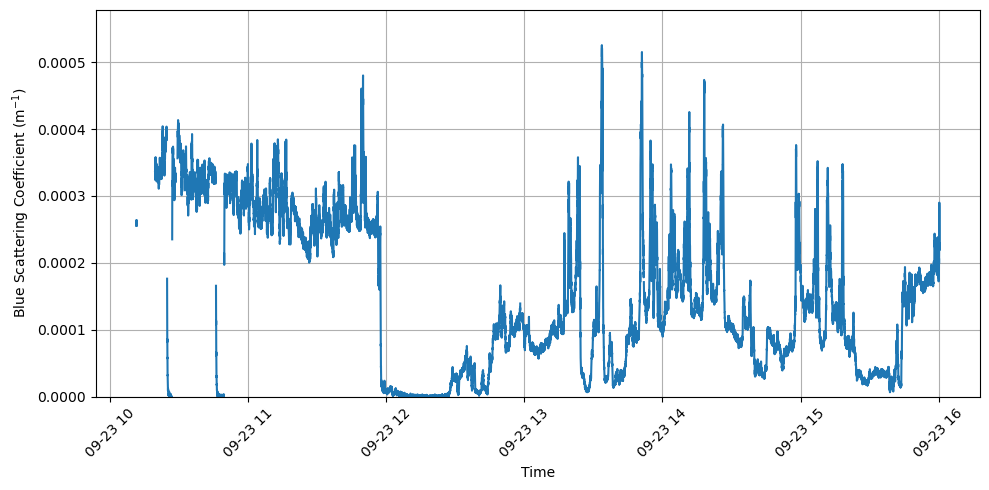

In [29]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(ds_neph['datetime'], ds_neph['TSC_BLUU'])

plt.xlabel('Time')
plt.ylabel(r'Blue Scattering Coefficient ($\mathrm{m^{-1}}$)')
plt.ylim(0,np.max(ds_neph['TSC_BLUU'])*1.1)
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

In [30]:
total_scattering_sum = np.nansum(ds_neph['TSC_BLUU'])  # Avoid NaNs in summation
total_scattering_sum

3.0209689702799998

In [18]:
# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    print(f"Files found in {path}:")
    print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Print or use the collected file paths
print("\nFiltered files:")
print(filtered_files)


Files found in /home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core_faam*r1*.nc:
['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core_faam_20120923_v004_r1_b739.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core_faam_20120923_v004_r1_b739_1hz.nc']

Filtered files:
['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core_faam_20120923_v004_r1_b739.nc']


In [19]:
# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
print(file_paths_ams)

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/non-core/man-ams_faam_20120923_r0_b739.na']


In [20]:
# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
print(file_paths_sp2)

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/non-core/man-sp2_faam_20120923_r0_b739.na']


In [21]:
print(len(file_paths_ams))
print(len(file_paths_sp2))
print(len(filtered_files))

1
1
1


In [22]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2  # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")


Common flights: ['b739']
Filtered NC files: 1
Filtered AMS files: 1
Filtered SP2 files: 1


In [23]:
filtered_nc

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core_faam_20120923_v004_r1_b739.nc']

In [42]:
ds_wet_neph = xr.open_dataset(filtered_nc[0])

# Filter out invalid NO3 values (9999999)
valid_neph_mask = ds_wet_neph["TSC_BLUU_FLAG"] == 0
filtered_ds_neph = ds_wet_neph.where(valid_neph_mask, drop=True)

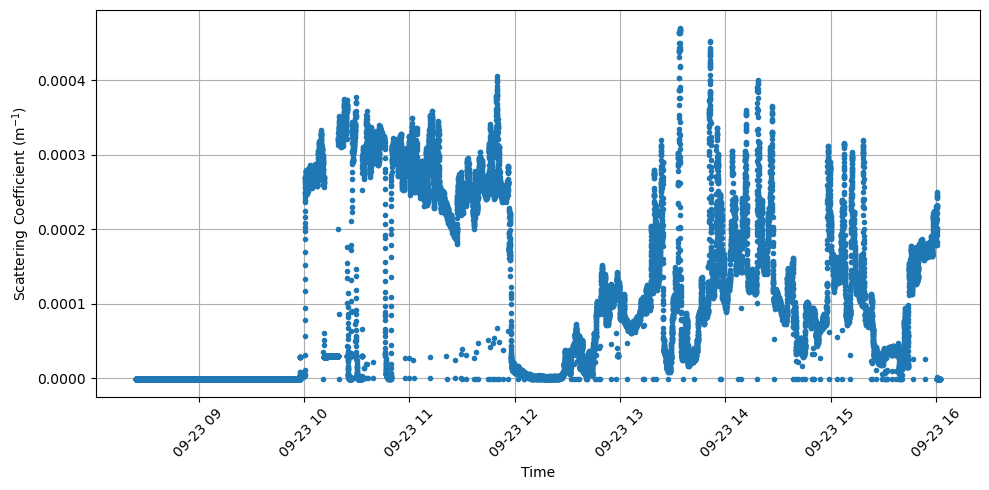

In [44]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(filtered_ds_neph['Time'], filtered_ds_neph['TSC_BLUU'], marker='.',linewidth=0)

plt.xlabel('Time')
plt.ylabel(r'Scattering Coefficient ($\mathrm{m^{-1}}$)')
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

In [38]:
dry_neph_time = ds_neph["datetime"].values  # Original timestamps from new dataset
wet_neph_time = ds_wet_neph["Time"].values  # Original timestamps from new dataset
common_times = np.intersect1d(wet_neph_time, dry_neph_time)

# Create a boolean mask as an Xarray DataArray
mask_dry = xr.DataArray(np.isin(dry_neph_time, common_times), dims=["time"])
mask_wet = xr.DataArray(np.isin(wet_neph_time, common_times), dims=["data_point"])

# Apply the mask to filter ds_psap
ds_dry_matched = ds_neph.where(mask_dry, drop=True)
ds_wet_matched = ds_wet_neph.where(mask_wet, drop=True)

In [49]:
print(ds_wet_matched['Time'][0])

<xarray.DataArray 'Time' ()> Size: 8B
array('2012-09-23T10:11:11.000000000', dtype='datetime64[ns]')
Attributes:
    long_name:      time of measurement                                      ...
    standard_name:  time


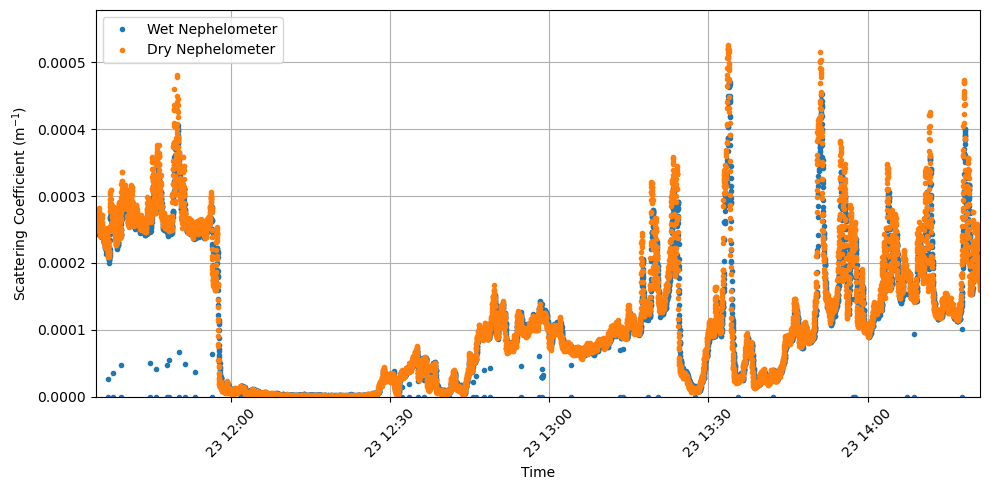

In [55]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(ds_wet_matched['Time'], ds_wet_matched['TSC_BLUU'],label='Wet Nephelometer', marker='.',linewidth=0)
plt.plot(ds_dry_matched['datetime'], ds_dry_matched['TSC_BLUU'],label='Dry Nephelometer', marker='.',linewidth=0)

plt.xlabel('Time')
plt.ylabel(r'Scattering Coefficient ($\mathrm{m^{-1}}$)')
plt.ylim(0,np.max(ds_dry_matched['TSC_BLUU'])*1.1)
plt.xlim(ds_wet_matched['Time'][5000],ds_wet_matched['Time'][15000])
plt.xticks(rotation=45)
plt.grid()
plt.legend()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()